# ecDNA / HSR integration window scan

This notebook:

1. Reads **normalized** Hi-C contact data from two `.mcool` files (**HSR** and **regular ecDNA**)
2. Reads ecDNA intervals from BED / cycle files
3. Computes **ecDNA→genome 1D interaction profiles** **block by block** (no full matrix load, no coarse-graining)
4. Finds **significant windows** in **both** HSR and regular Hi-C using a one-sided Mann–Whitney/Wilcoxon rank-sum test against local background
5. Computes **HSR vs regular log2 fold change**
6. Filters candidate windows using:
   - `q_HSR < QVAL_THRESHOLD`
   - `log2FC_HSR_vs_REG > LOG2FC_THRESHOLD`
7. Maps top candidate bins back to **genomic coordinates**

Update the paths and parameters in the config cell, then run all cells.


In [1]:

import os
import time
import warnings
import numpy as np
import pandas as pd
import cooler
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from math import erf, sqrt

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 130


In [2]:

# =========================
# CONFIG
# =========================

BASE_DIR = "/Users/sehaj/Developer-UW/ucsd-cse-280a/CSE280A_Team_4"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

RESOLUTION = 25000

HSR = dict(
    cool=f"{DATA_DIR}/GBM39HSR.mcool::resolutions/{RESOLUTION}",
    bed=f"{DATA_DIR}/GBM39HSR_ecDNA.bed",
    label="GBM39 HSR",
)

REG = dict(
    cool=f"{DATA_DIR}/GBM39ec.mcool::resolutions/{RESOLUTION}",
    bed=f"{DATA_DIR}/GBM39_ecDNA.bed",
    label="GBM39 ecDNA",
)

# Choose a normalization column present in the bins table.
# Available in your data: KR, SCALE, VC, VC_SQRT
BALANCE = "SCALE"

# Window scan parameters
EPS = 1e-8
WINDOW_RADIUS = 2          # signal window = 2*WINDOW_RADIUS + 1 bins
BACKGROUND_RADIUS = 20     # local background radius
USE_MEDIAN = True          # summarize window log2FC by median instead of mean
TOP_K = 25

# Filtering thresholds
QVAL_THRESHOLD = 0.05
LOG2FC_THRESHOLD = 1.0     # 1.0 => HSR is at least 2x stronger than regular
ZSCORE_THRESHOLD = 3.0

_ORDERED = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]


In [3]:

# =========================
# ecDNA interval reader
# =========================
try:
    from ec3d.util import read_ecDNA_cycle
except ImportError:
    try:
        from util import read_ecDNA_cycle
    except ImportError:
        def read_ecDNA_cycle(path, resolution):
            intervals = []
            with open(path) as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith("#"):
                        continue
                    parts = line.split()
                    chrom = parts[0]
                    start = (int(parts[1]) // resolution) * resolution
                    end = ((int(parts[2]) + resolution - 1) // resolution) * resolution
                    ori = parts[3] if len(parts) > 3 else "+"
                    intervals.append((chrom, start, end, ori))
            return intervals

# =========================
# Helpers
# =========================
def ordered_chroms(clr_chromnames):
    names = set(clr_chromnames) - {"chrM", "M"}
    result = [c for c in _ORDERED if c in names]
    result += sorted(names - set(result))
    return result

def resolve_chrom_name(chrom, clr_chromnames):
    names = set(clr_chromnames)
    if chrom in names:
        return chrom
    if chrom.startswith("chr") and chrom[3:] in names:
        return chrom[3:]
    if (not chrom.startswith("chr")) and ("chr" + chrom) in names:
        return "chr" + chrom
    return None

def interval_to_str(chrom, start, end):
    return f"{chrom}:{start}-{end}"

def get_balance_col(clr, balance):
    cols = list(clr.bins()[:].columns)
    if balance not in cols:
        available = [c for c in cols if c not in ("chrom", "start", "end")]
        raise ValueError(
            f"Normalization column '{balance}' not found in {clr.filename}. "
            f"Available columns: {available}"
        )
    return balance

def get_weight_array(df, balance):
    w = df[balance].to_numpy(dtype=np.float64)
    return np.nan_to_num(w, nan=0.0, posinf=0.0, neginf=0.0)

def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    qvals = np.empty(n, dtype=float)

    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        q = ranked[i] * n / rank
        prev = min(prev, q)
        qvals[i] = prev

    out = np.empty(n, dtype=float)
    out[order] = np.clip(qvals, 0, 1)
    return out

def extract_signal_and_background(profile: np.ndarray, center: int,
                                  window_radius: int,
                                  background_radius: int):
    n = len(profile)
    left = max(0, center - background_radius)
    right = min(n, center + background_radius + 1)

    sig_left = max(0, center - window_radius)
    sig_right = min(n, center + window_radius + 1)

    signal = profile[sig_left:sig_right]

    bg_left = profile[left:sig_left]
    bg_right = profile[sig_right:right]
    background = np.concatenate([bg_left, bg_right])

    return signal, background, sig_left, sig_right

def score_windows(profile: np.ndarray,
                  window_radius: int,
                  background_radius: int):
    results = []
    for center in range(len(profile)):
        signal, background, sig_left, sig_right = extract_signal_and_background(
            profile, center, window_radius, background_radius
        )

        if len(signal) < 2 or len(background) < 5:
            results.append((center, np.nan, np.nan, np.nan, sig_left, sig_right))
            continue

        try:
            _, pval = mannwhitneyu(signal, background, alternative="greater")
        except ValueError:
            pval = np.nan

        signal_mean = np.mean(signal)
        background_mean = np.mean(background)
        results.append((center, pval, signal_mean, background_mean, sig_left, sig_right))

    centers = np.array([r[0] for r in results], dtype=int)
    pvals = np.array([r[1] for r in results], dtype=float)
    signal_means = np.array([r[2] for r in results], dtype=float)
    background_means = np.array([r[3] for r in results], dtype=float)
    sig_lefts = np.array([r[4] for r in results], dtype=int)
    sig_rights = np.array([r[5] for r in results], dtype=int)

    qvals = np.full_like(pvals, np.nan)
    valid = ~np.isnan(pvals)
    if np.any(valid):
        qvals[valid] = bh_fdr(pvals[valid])

    neglog10p = -np.log10(np.clip(pvals, 1e-300, 1.0))
    neglog10q = -np.log10(np.clip(qvals, 1e-300, 1.0))

    return dict(
        centers=centers,
        pvals=pvals,
        qvals=qvals,
        neglog10p=neglog10p,
        neglog10q=neglog10q,
        signal_means=signal_means,
        background_means=background_means,
        sig_lefts=sig_lefts,
        sig_rights=sig_rights,
    )

def normal_sf(z):
    """
    One-sided survival function for standard normal:
    P(Z >= z)
    """
    return 0.5 * (1.0 - erf(z / sqrt(2.0)))

def score_windows_z(profile: np.ndarray,
                    window_radius: int,
                    background_radius: int,
                    min_bg: int = 5,
                    use_log: bool = True,
                    sd_floor: float = 1e-6):
    """
    Bin-level local z-score enrichment against immediate background.

    For each center bin i:
      - signal = profile[i] only
      - background = nearby flanking bins returned by extract_signal_and_background
      - z = (center_value - background_mean) / background_sd

    window_radius is kept only so the saved window_start/window_end fields
    remain consistent with the rest of the notebook.
    """
    if use_log:
        prof = np.log2(profile + 1.0)
    else:
        prof = profile.copy()

    results = []
    for center in range(len(prof)):
        signal, background, sig_left, sig_right = extract_signal_and_background(
            prof, center, window_radius, background_radius
        )

        center_value = prof[center]

        if len(background) < min_bg:
            results.append((center, np.nan, np.nan, center_value, np.nan, np.nan, sig_left, sig_right))
            continue

        background_mean = np.mean(background)
        background_sd = 1.4826 * np.median(np.abs(background - np.median(background)))
        background_sd = max(background_sd, 0.05)

        if not np.isfinite(background_sd):
            z = np.nan
            pval = np.nan
        else:
            background_sd = max(background_sd, sd_floor)
            z = (center_value - background_mean) / background_sd
            pval = normal_sf(z)

        results.append((center, z, pval, center_value, background_mean, background_sd, sig_left, sig_right))

    centers = np.array([r[0] for r in results], dtype=int)
    zscores = np.array([r[1] for r in results], dtype=float)
    pvals = np.array([r[2] for r in results], dtype=float)
    signal_means = np.array([r[3] for r in results], dtype=float)   # now actually center-bin values
    background_means = np.array([r[4] for r in results], dtype=float)
    background_sds = np.array([r[5] for r in results], dtype=float)
    sig_lefts = np.array([r[6] for r in results], dtype=int)
    sig_rights = np.array([r[7] for r in results], dtype=int)

    qvals = np.full_like(pvals, np.nan)
    valid = ~np.isnan(pvals)
    if np.any(valid):
        qvals[valid] = bh_fdr(pvals[valid])

    neglog10p = -np.log10(np.clip(pvals, 1e-300, 1.0))
    neglog10q = -np.log10(np.clip(qvals, 1e-300, 1.0))

    return dict(
        centers=centers,
        zscores=zscores,
        pvals=pvals,
        qvals=qvals,
        neglog10p=neglog10p,
        neglog10q=neglog10q,
        signal_means=signal_means,      # center-bin value
        background_means=background_means,
        background_sds=background_sds,
        sig_lefts=sig_lefts,
        sig_rights=sig_rights,
    )

def save_window_results(path, stats_dict, extra_cols=None):
    df = pd.DataFrame({
        "center_bin": stats_dict["centers"],
        "window_start": stats_dict["sig_lefts"],
        "window_end": stats_dict["sig_rights"] - 1,
        "pval": stats_dict["pvals"],
        "qval": stats_dict["qvals"],
        "neglog10p": stats_dict["neglog10p"],
        "neglog10q": stats_dict["neglog10q"],
        "signal_mean": stats_dict["signal_means"],
        "background_mean": stats_dict["background_means"],
    })

    if "zscores" in stats_dict:
        df["zscore"] = stats_dict["zscores"]
    if "background_sds" in stats_dict:
        df["background_sd"] = stats_dict["background_sds"]

    if extra_cols is not None:
        for k, v in extra_cols.items():
            df[k] = v

    df.to_csv(path, sep="\t", index=False)
    print(f"Saved: {path}")
    return df


In [4]:

# =========================
# Block-wise ecDNA→genome profile extraction
# =========================
def prepare_intervals(clr, bed_path, resolution, balance):
    raw_intrvls = read_ecDNA_cycle(bed_path, resolution)
    resolved = []

    for chrom, start, end, ori in raw_intrvls:
        ch = resolve_chrom_name(chrom, clr.chromnames)
        if ch is None:
            print(f"WARNING: interval {chrom}:{start}-{end} not found in cooler; skipping.")
            continue

        region = interval_to_str(ch, start, end)
        try:
            bins_df = clr.bins().fetch(region)
        except Exception:
            print(f"WARNING: could not fetch {region}; skipping.")
            continue

        if len(bins_df) == 0:
            continue

        weights = get_weight_array(bins_df, balance)
        resolved.append({
            "chrom": ch,
            "start": start,
            "end": end,
            "ori": ori,
            "region": region,
            "n_bins": len(bins_df),
            "weights": weights
        })

    if not resolved:
        raise ValueError(f"No valid ecDNA intervals found in {bed_path}")

    total_ec_bins = sum(r["n_bins"] for r in resolved)
    print(f"  Loaded {len(resolved)} ecDNA interval(s), total ecDNA bins = {total_ec_bins}")
    return resolved, total_ec_bins

def build_ec_vs_genome_profile(clr, intrvls_prepared, total_ec_bins, balance, chroms):
    """
    profile[j] = mean normalized interaction between all ecDNA bins and genome bin j
    computed chromosome-by-chromosome, interval-by-interval.
    """
    profile_parts = []
    chrom_offsets = {}
    cursor = 0

    print("  Building ecDNA→genome profile block by block ...")
    t0 = time.time()

    for ch_idx, ch in enumerate(chroms):
        chr_bins_df = clr.bins().fetch(ch)
        n_chr_bins = len(chr_bins_df)
        chrom_offsets[ch] = cursor
        cursor += n_chr_bins

        col_weights = get_weight_array(chr_bins_df, balance)
        chrom_sum = np.zeros(n_chr_bins, dtype=np.float64)

        for intr in intrvls_prepared:
            region = intr["region"]
            row_weights = intr["weights"]

            try:
                block = clr.matrix(balance=False, sparse=True).fetch(region, ch)
            except Exception as e:
                print(f"    WARNING: failed to fetch block {region} vs {ch}: {e}")
                continue

            if block.nnz == 0:
                continue

            vals = block.data.astype(np.float64)
            vals = vals * row_weights[block.row] * col_weights[block.col]

            np.add.at(chrom_sum, block.col, vals)

        chrom_profile = chrom_sum / max(total_ec_bins, 1)
        profile_parts.append(chrom_profile)

        print(
            f"    {ch_idx+1:2d}/{len(chroms)}  {ch:>5s}  bins={n_chr_bins:>7,d}  "
            f"time={time.time()-t0:.1f}s",
            flush=True
        )

    profile = np.concatenate(profile_parts)
    return profile, chrom_offsets

def build_bin_table(clr, chroms):
    dfs = []
    for ch in chroms:
        df = clr.bins().fetch(ch)[["chrom", "start", "end"]].copy()
        dfs.append(df)
    out = pd.concat(dfs, axis=0, ignore_index=True)
    out["genome_bin_index"] = np.arange(len(out))
    return out


In [5]:

# =========================
# Load data and build profiles
# =========================
print("=" * 80)
print("Loading coolers...")

clr_hsr = cooler.Cooler(HSR["cool"])
clr_reg = cooler.Cooler(REG["cool"])

if clr_hsr.binsize != RESOLUTION or clr_reg.binsize != RESOLUTION:
    raise ValueError(
        f"Resolution mismatch: HSR={clr_hsr.binsize}, REG={clr_reg.binsize}, CONFIG={RESOLUTION}"
    )

get_balance_col(clr_hsr, BALANCE)
get_balance_col(clr_reg, BALANCE)

chroms_hsr = ordered_chroms(clr_hsr.chromnames)
chroms_reg = ordered_chroms(clr_reg.chromnames)
chroms = [c for c in chroms_hsr if c in set(chroms_reg)]

print(f"Using chromosomes ({len(chroms)}): {chroms}")
print(f"Normalization column: {BALANCE}\n")

print(f"Preparing ecDNA intervals for {HSR['label']} ...")
hsr_intrvls, hsr_total_ec_bins = prepare_intervals(clr_hsr, HSR["bed"], RESOLUTION, BALANCE)

print(f"Preparing ecDNA intervals for {REG['label']} ...")
reg_intrvls, reg_total_ec_bins = prepare_intervals(clr_reg, REG["bed"], RESOLUTION, BALANCE)
print()

print(f"Computing profile for {HSR['label']} ...")
hsr_profile, _ = build_ec_vs_genome_profile(
    clr_hsr, hsr_intrvls, hsr_total_ec_bins, BALANCE, chroms
)

print(f"\nComputing profile for {REG['label']} ...")
reg_profile, _ = build_ec_vs_genome_profile(
    clr_reg, reg_intrvls, reg_total_ec_bins, BALANCE, chroms
)

if len(hsr_profile) != len(reg_profile):
    raise ValueError(
        f"Profile length mismatch: HSR={len(hsr_profile)}, REG={len(reg_profile)}"
    )

np.save(os.path.join(RESULTS_DIR, "hsr_ec_vs_genome_profile.npy"), hsr_profile)
np.save(os.path.join(RESULTS_DIR, "reg_ec_vs_genome_profile.npy"), reg_profile)

bins_df = build_bin_table(clr_hsr, chroms)
bins_df.to_csv(os.path.join(RESULTS_DIR, "genome_bin_annotations.tsv"), sep="\t", index=False)

print("\nProfiles saved.")
print("Profile length:", len(hsr_profile))
print("First 10 HSR values:", hsr_profile[:10])
print("First 10 regular values:", reg_profile[:10])


Loading coolers...
Using chromosomes (24): ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX', 'chrY']
Normalization column: SCALE

Preparing ecDNA intervals for GBM39 HSR ...
+
+
+
  Loaded 3 ecDNA interval(s), total ecDNA bins = 50
Preparing ecDNA intervals for GBM39 ecDNA ...
+
+
+
  Loaded 3 ecDNA interval(s), total ecDNA bins = 50

Computing profile for GBM39 HSR ...
  Building ecDNA→genome profile block by block ...
     1/24   chr1  bins=  9,959  time=1.2s
     2/24   chr2  bins=  9,688  time=2.3s
     3/24   chr3  bins=  7,932  time=3.4s
     4/24   chr4  bins=  7,609  time=4.2s
     5/24   chr5  bins=  7,262  time=4.9s
     6/24   chr6  bins=  6,833  time=5.5s
     7/24   chr7  bins=  6,374  time=6.0s
     8/24   chr8  bins=  5,806  time=6.1s
     9/24   chr9  bins=  5,536  time=6.2s
    10/24  chr10  bins=  5,352  time=6.2s
    11/2

In [6]:

# =========================
# Window significance + HSR vs regular comparison
# =========================
print("Scoring windows in HSR profile with Wilcoxon ...")
hsr_wilcox = score_windows(hsr_profile, WINDOW_RADIUS, BACKGROUND_RADIUS)

print("Scoring windows in HSR profile with z-score ...")
hsr_z = score_windows_z(hsr_profile, WINDOW_RADIUS, BACKGROUND_RADIUS)

print("Scoring windows in regular ecDNA profile with Wilcoxon ...")
reg_wilcox = score_windows(reg_profile, WINDOW_RADIUS, BACKGROUND_RADIUS)

print("Scoring windows in regular ecDNA profile with z-score ...")
reg_z = score_windows_z(reg_profile, WINDOW_RADIUS, BACKGROUND_RADIUS)

save_window_results(os.path.join(RESULTS_DIR, "hsr_wilcoxon_windows.tsv"), hsr_wilcox)
save_window_results(os.path.join(RESULTS_DIR, "hsr_zscore_windows.tsv"), hsr_z)

save_window_results(os.path.join(RESULTS_DIR, "reg_wilcoxon_windows.tsv"), reg_wilcox)
save_window_results(os.path.join(RESULTS_DIR, "reg_zscore_windows.tsv"), reg_z)

per_bin_log2fc = np.log2((hsr_profile + EPS) / (reg_profile + EPS))

window_log2fc = np.full(len(hsr_profile), np.nan, dtype=float)
for i in range(len(hsr_profile)):
    left = hsr_wilcox["sig_lefts"][i]
    right = hsr_wilcox["sig_rights"][i]
    vals = per_bin_log2fc[left:right]
    if len(vals) == 0:
        continue
    window_log2fc[i] = np.median(vals) if USE_MEDIAN else np.mean(vals)

# Suggested candidate rule:
#   significant in HSR by q-value
#   sufficiently stronger in HSR than regular by log2FC
candidate_mask_w = (
    np.isfinite(hsr_wilcox["qvals"]) &
    (hsr_wilcox["qvals"] < QVAL_THRESHOLD) &
    np.isfinite(window_log2fc) &
    (window_log2fc > LOG2FC_THRESHOLD)
)
candidate_score = np.where(candidate_mask_w, window_log2fc, np.nan)

# z-score-based window log2 fold-change: HSR vs regular
window_log2fc_z = per_bin_log2fc.copy()

candidate_mask_z = (
    np.isfinite(hsr_z["zscores"]) &
    (hsr_z["zscores"] >= ZSCORE_THRESHOLD) &
    np.isfinite(hsr_z["qvals"]) &
    (hsr_z["qvals"] < QVAL_THRESHOLD) &
    np.isfinite(window_log2fc_z) &
    (window_log2fc_z > LOG2FC_THRESHOLD)
)

candidates_z = pd.DataFrame({
    "center_bin": hsr_z["centers"][candidate_mask_z],
    "window_start": hsr_z["sig_lefts"][candidate_mask_z],
    "window_end": hsr_z["sig_rights"][candidate_mask_z] - 1,
    "zscore": hsr_z["zscores"][candidate_mask_z],
    "z_pval": hsr_z["pvals"][candidate_mask_z],
    "z_qval": hsr_z["qvals"][candidate_mask_z],
    "signal_mean": hsr_z["signal_means"][candidate_mask_z],
    "background_mean": hsr_z["background_means"][candidate_mask_z],
    "background_sd": hsr_z["background_sds"][candidate_mask_z],
    "window_log2fc": window_log2fc_z[candidate_mask_z],
})

candidates_z = candidates_z.sort_values(
    ["zscore", "z_qval", "window_log2fc"],
    ascending=[False, True, False]
).reset_index(drop=True)

display(candidates_z.head(20))

candidates_z.to_csv(
    os.path.join(RESULTS_DIR, "candidate_windows_zscore.tsv"),
    sep="\t",
    index=False
)

print(f"Z-score candidates: {len(candidates_z)}")


Scoring windows in HSR profile with Wilcoxon ...
Scoring windows in HSR profile with z-score ...
Scoring windows in regular ecDNA profile with Wilcoxon ...
Scoring windows in regular ecDNA profile with z-score ...
Saved: /Users/sehaj/Developer-UW/ucsd-cse-280a/CSE280A_Team_4/results/hsr_wilcoxon_windows.tsv
Saved: /Users/sehaj/Developer-UW/ucsd-cse-280a/CSE280A_Team_4/results/hsr_zscore_windows.tsv
Saved: /Users/sehaj/Developer-UW/ucsd-cse-280a/CSE280A_Team_4/results/reg_wilcoxon_windows.tsv
Saved: /Users/sehaj/Developer-UW/ucsd-cse-280a/CSE280A_Team_4/results/reg_zscore_windows.tsv


,center_bin,window_start,window_end,zscore,z_pval,z_qval,signal_mean,background_mean,background_sd,window_log2fc
0,5007,5005,5009,248.928178,0.0,0.0,12.542080,0.095672,0.05,7.460192
1,111361,111359,111363,178.755469,0.0,0.0,8.958297,0.020523,0.05,6.099356
2,123525,123523,123527,116.756598,0.0,0.0,5.987620,0.149790,0.05,1.730083
3,4,2,6,112.907784,0.0,0.0,5.757420,0.112031,0.05,10.380252
4,122308,122306,122310,108.234442,0.0,0.0,5.517102,0.105379,0.05,32.060674
5,37173,37171,37175,106.327879,0.0,0.0,5.318672,0.002278,0.05,8.065130
6,113403,113401,113405,102.106947,0.0,0.0,5.262737,0.157389,0.05,8.668441
7,121946,121944,121948,94.384752,0.0,0.0,5.084065,0.364827,0.05,8.226606
8,63977,63975,63979,86.748738,0.0,0.0,4.521410,0.183973,0.05,2.586284
9,111445,111443,111447,86.208546,0.0,0.0,4.467149,0.156722,0.05,1.502652


Z-score candidates: 669


In [7]:

# =========================
# Map top candidate bins to genomic coordinates
# =========================
bins_lookup = bins_df.set_index("genome_bin_index")

candidate_centers = hsr_wilcox["centers"][candidate_mask_w]
candidate_scores = candidate_score[candidate_mask_w]

order = np.argsort(candidate_scores)[::-1]
top_centers = candidate_centers[order][:TOP_K]

top_rows = []
for c in top_centers:
    i = int(c)
    row = bins_lookup.loc[i]
    top_rows.append({
        "center_bin": i,
        "chrom": row["chrom"],
        "start": int(row["start"]),
        "end": int(row["end"]),
        "window_start_bin": int(hsr_wilcox["sig_lefts"][i]),
        "window_end_bin": int(hsr_wilcox["sig_rights"][i] - 1),
        "pval_hsr": float(hsr_wilcox["pvals"][i]),
        "qval_hsr": float(hsr_wilcox["qvals"][i]),
        "neglog10p_hsr": float(hsr_wilcox["neglog10p"][i]),
        "window_log2fc_hsr_vs_reg": float(window_log2fc[i]),
        "hsr_signal_mean": float(hsr_wilcox["signal_means"][i]),
        "hsr_background_mean": float(hsr_wilcox["background_means"][i]),
        "candidate_score": float(candidate_score[i]),
        "reg_qval_same_window": float(reg_wilcox["qvals"][i]) if np.isfinite(reg_wilcox["qvals"][i]) else np.nan,
    })

top_df = pd.DataFrame(top_rows)
top_path = os.path.join(RESULTS_DIR, "top_candidate_integration_windows.tsv")
top_df.to_csv(top_path, sep="\t", index=False)

print(f"Saved: {top_path}")
top_df


Saved: /Users/sehaj/Developer-UW/ucsd-cse-280a/CSE280A_Team_4/results/top_candidate_integration_windows.tsv


,center_bin,chrom,start,end,window_start_bin,window_end_bin,pval_hsr,qval_hsr,neglog10p_hsr,window_log2fc_hsr_vs_reg,hsr_signal_mean,hsr_background_mean,candidate_score,reg_qval_same_window
0,92626,chr15,17050000,17075000,92624,92628,2.459676e-06,0.025362,5.609122,24.845218,0.257974,0.000249,24.845218,0.604680
1,92625,chr15,17025000,17050000,92623,92627,2.459676e-06,0.025362,5.609122,24.845218,0.257974,0.000249,24.845218,0.604680
2,64364,chr9,72525000,72550000,64362,64366,5.337618e-06,0.034706,5.272653,3.520238,7.996289,3.075557,3.520238,0.458470
3,48545,chr6,152375000,152400000,48543,48547,5.337618e-06,0.034706,5.272653,3.490492,9.899360,4.158707,3.490492,0.307698
4,25879,chr3,155800000,155825000,25877,25881,2.668809e-06,0.025362,5.573683,2.988716,10.491289,6.179547,2.988716,0.637874
5,77260,chr11,122725000,122750000,77258,77262,5.337618e-06,0.034706,5.272653,2.919113,9.259626,5.014649,2.919113,0.389622
6,48546,chr6,152400000,152425000,48544,48548,2.668809e-06,0.025362,5.573683,2.842774,10.175976,4.194696,2.842774,0.178884
7,80264,chr12,62725000,62750000,80262,80266,9.340831e-06,0.046159,5.029614,2.800227,7.577347,2.922885,2.800227,0.079679
8,78528,chr12,19325000,19350000,78526,78530,2.668809e-06,0.025362,5.573683,2.669907,5.299193,1.837186,2.669907,0.349716
9,5902,chr1,147550000,147575000,5900,5904,1.334404e-06,0.025362,5.874713,2.468590,6.584260,3.220906,2.468590,0.520006


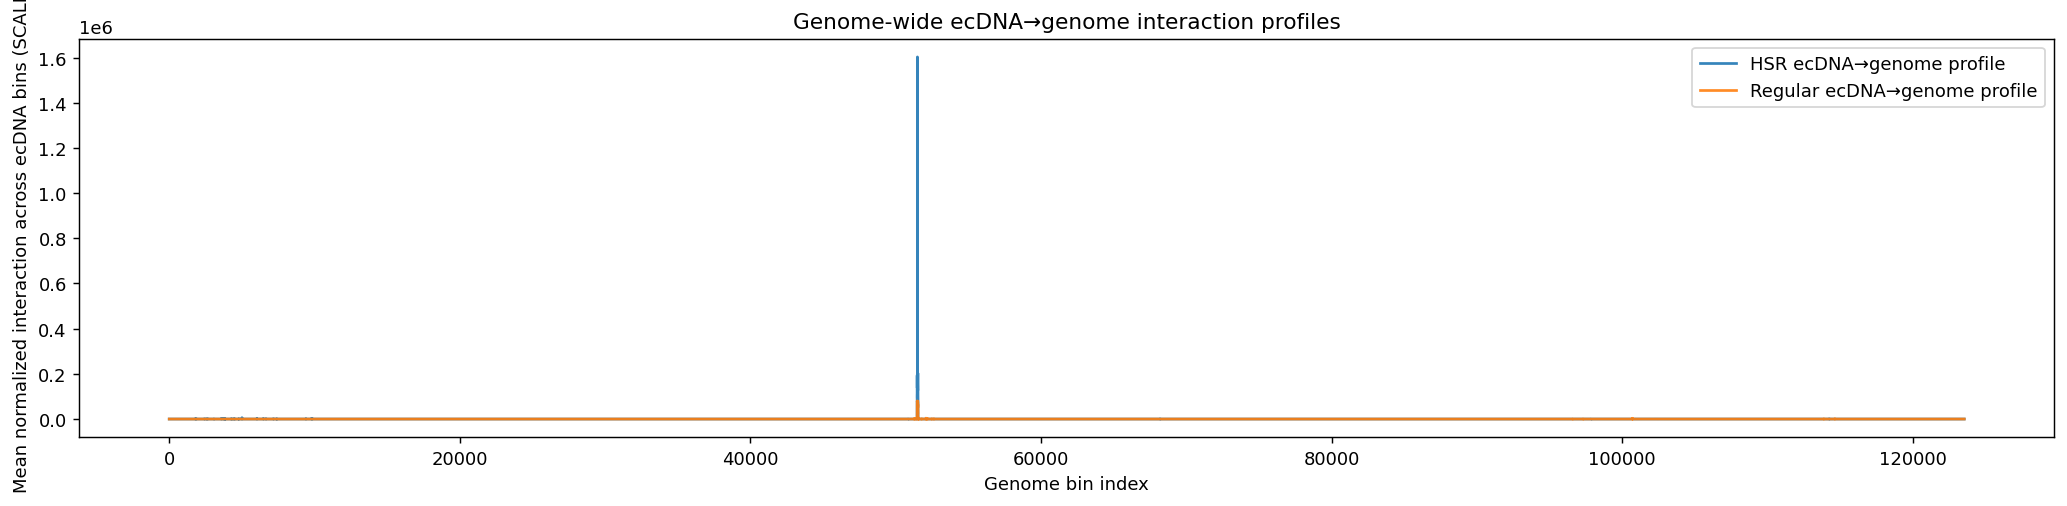

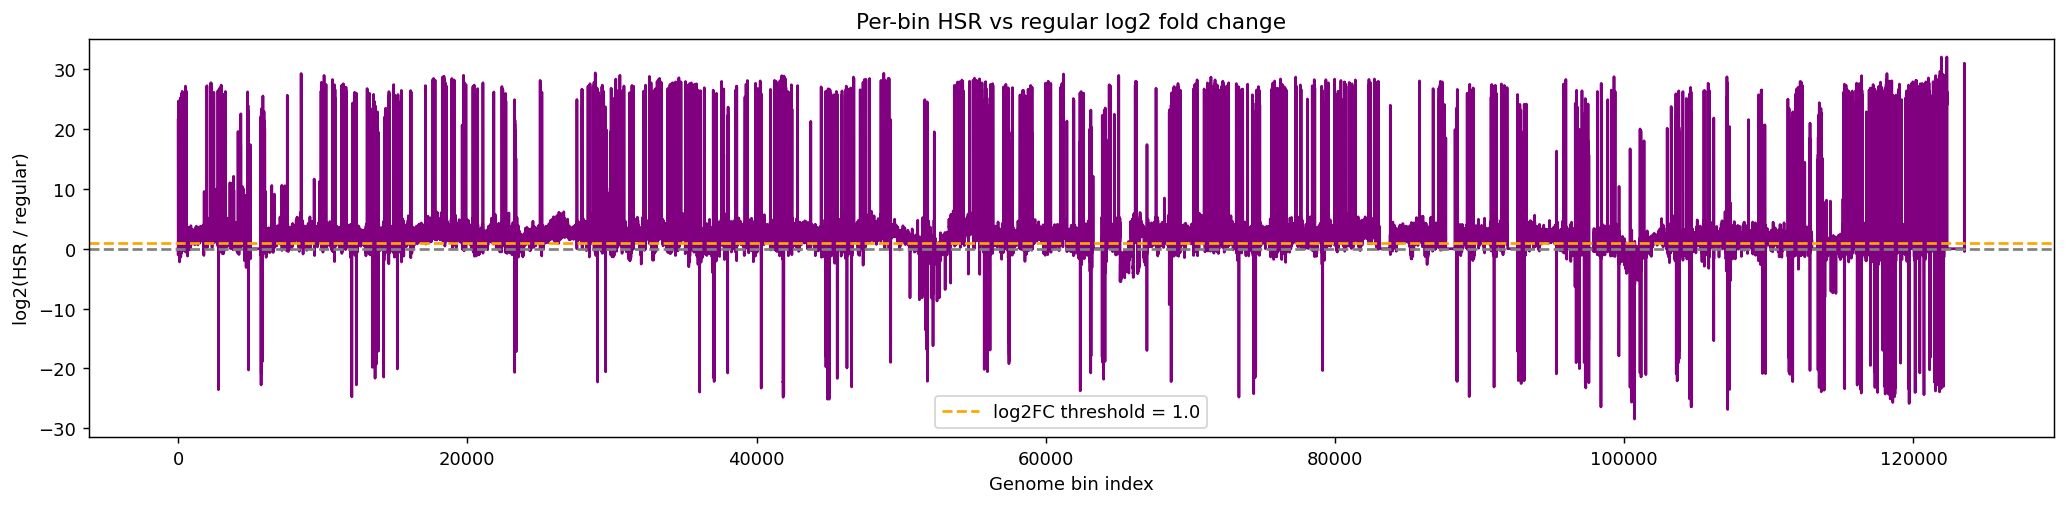

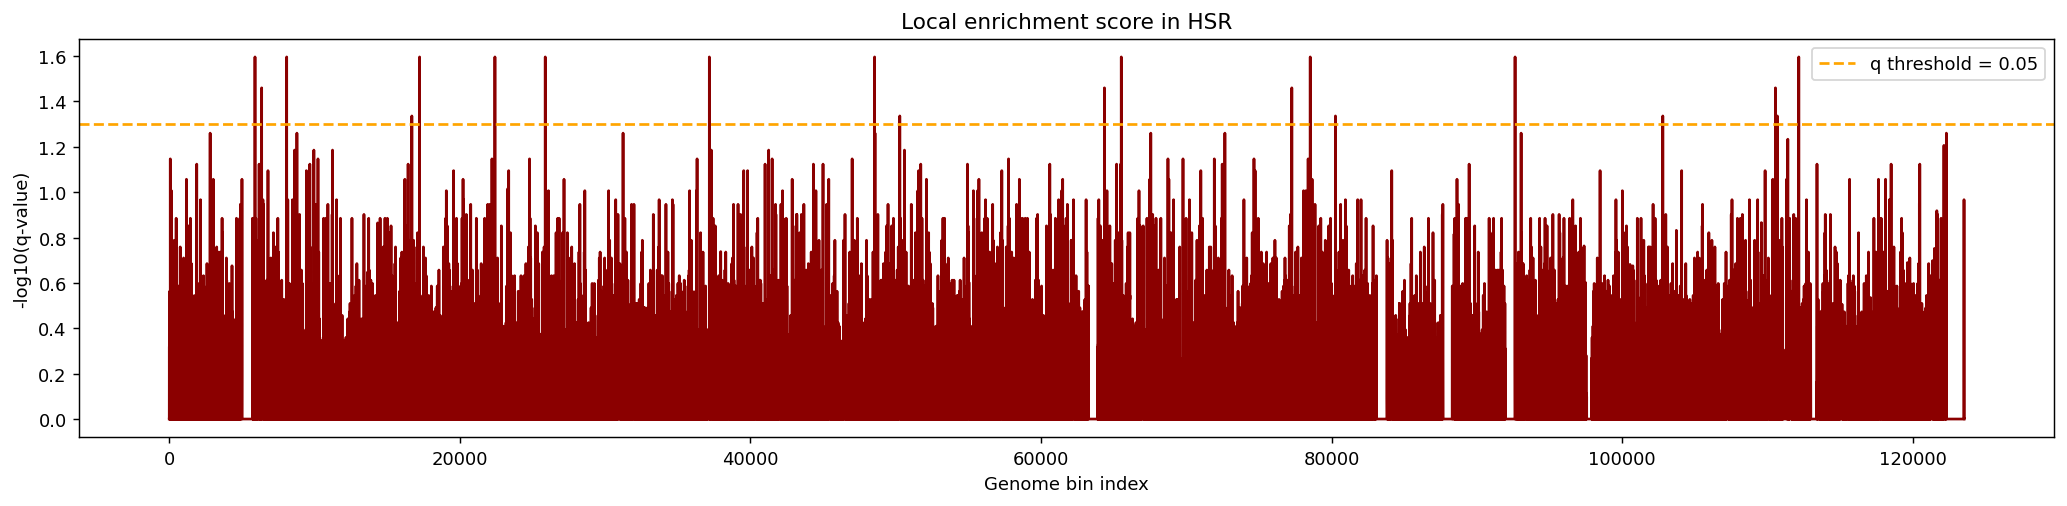

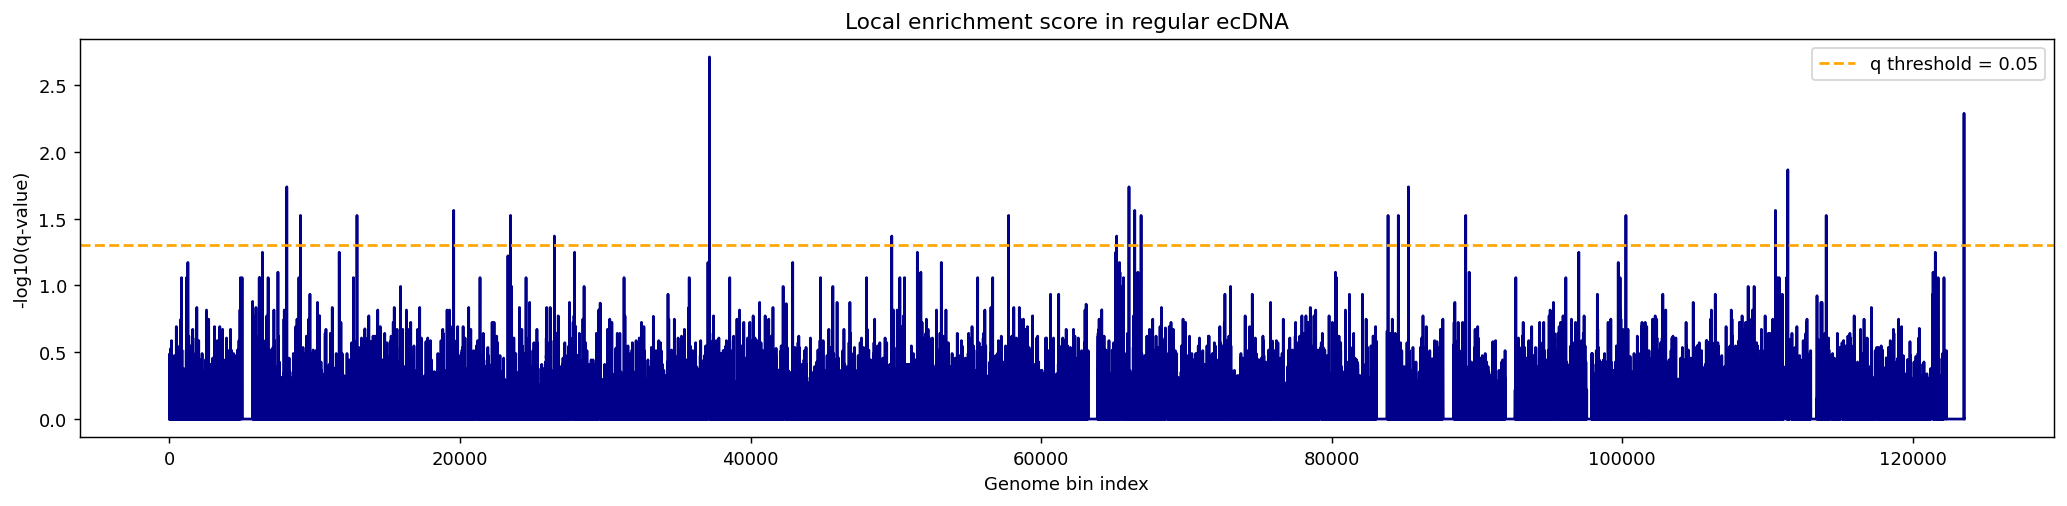

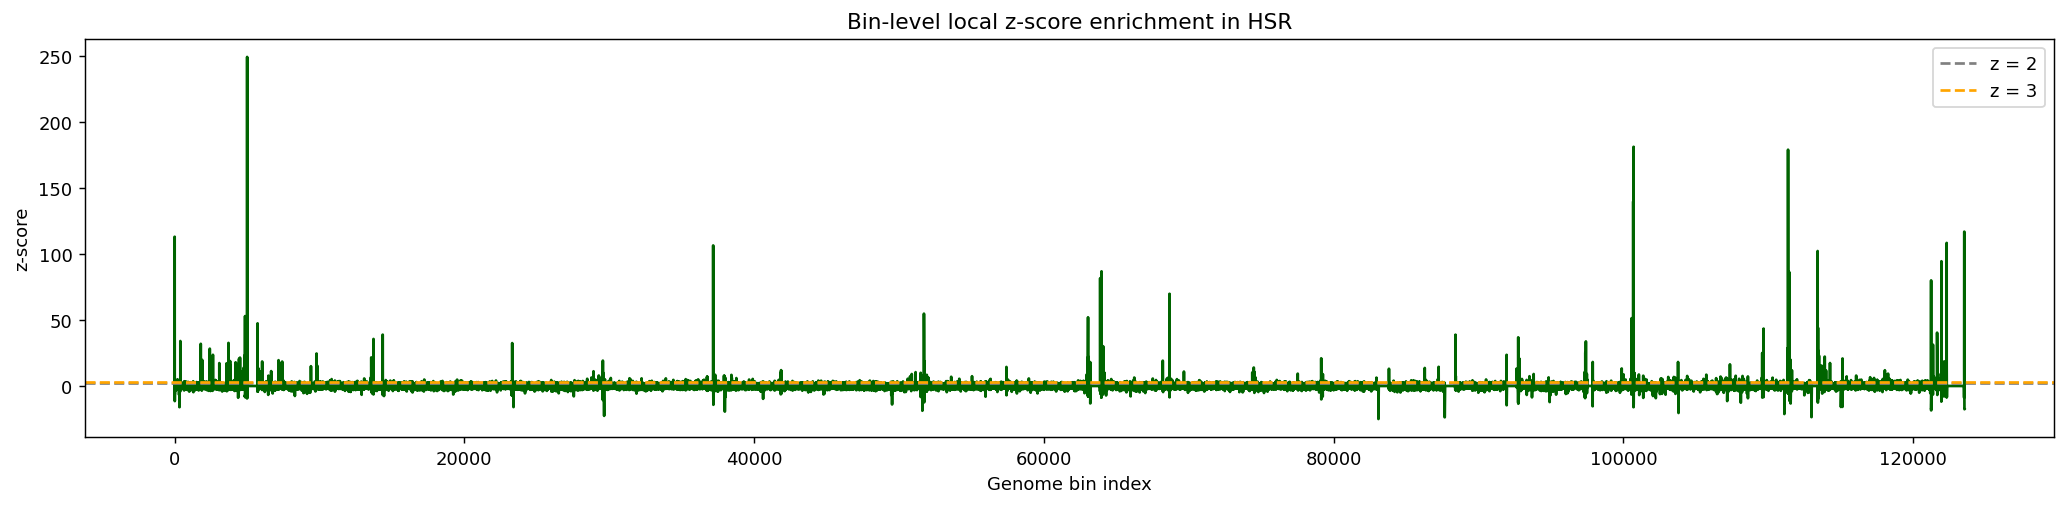

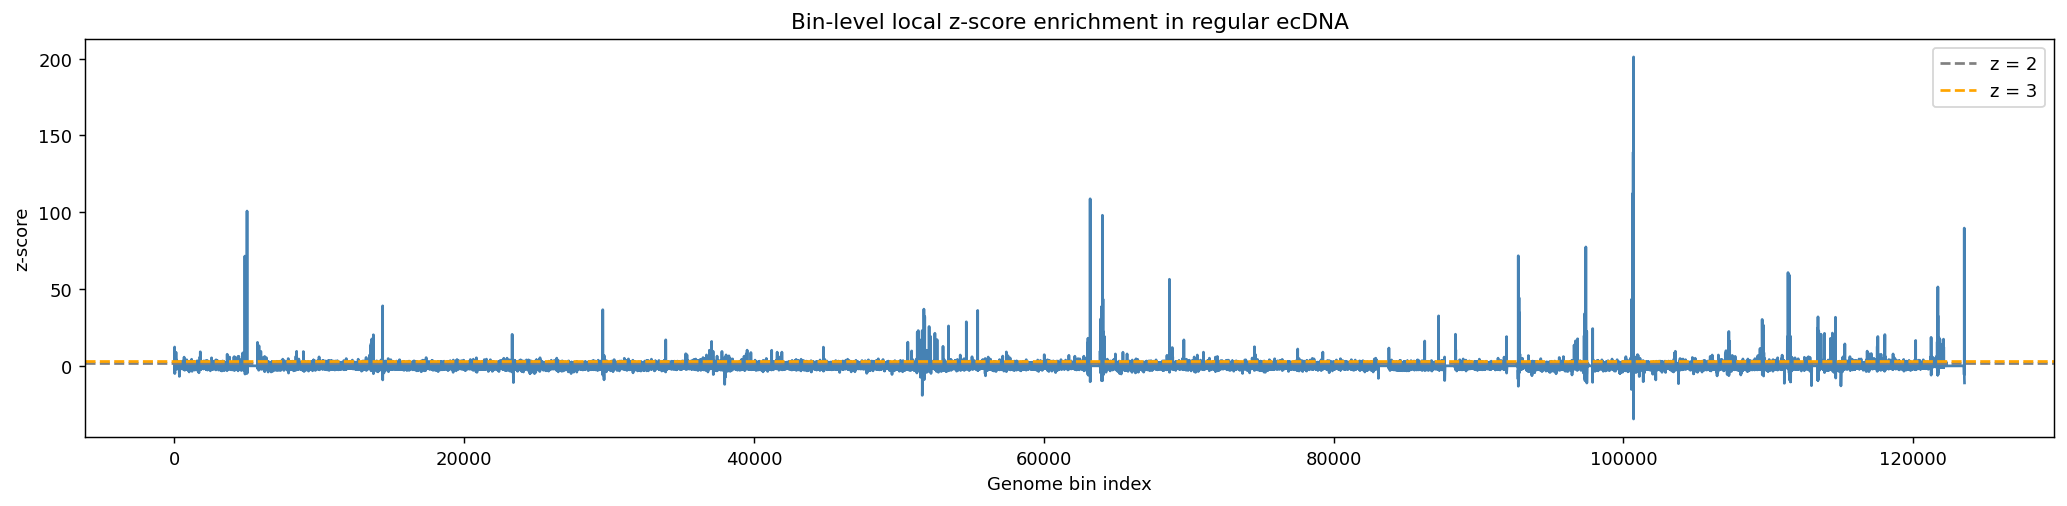

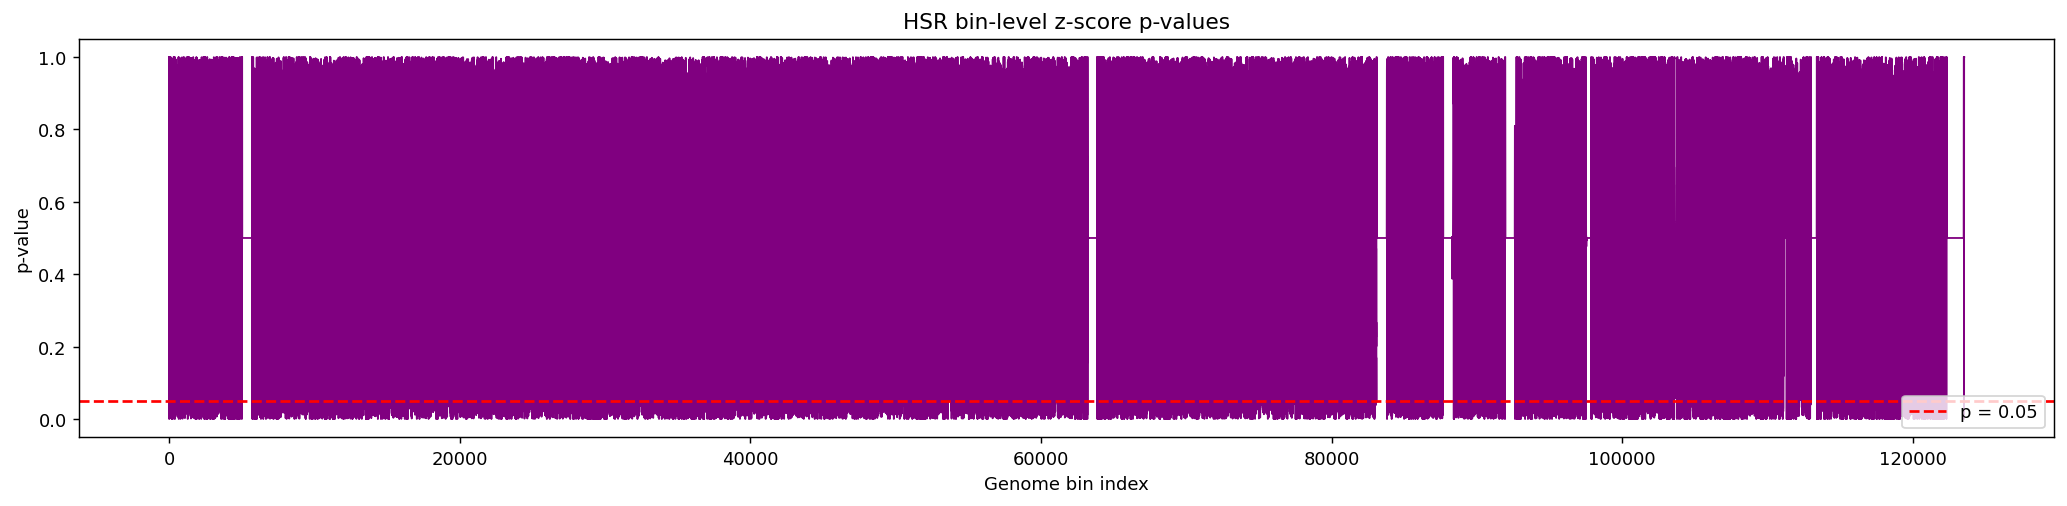

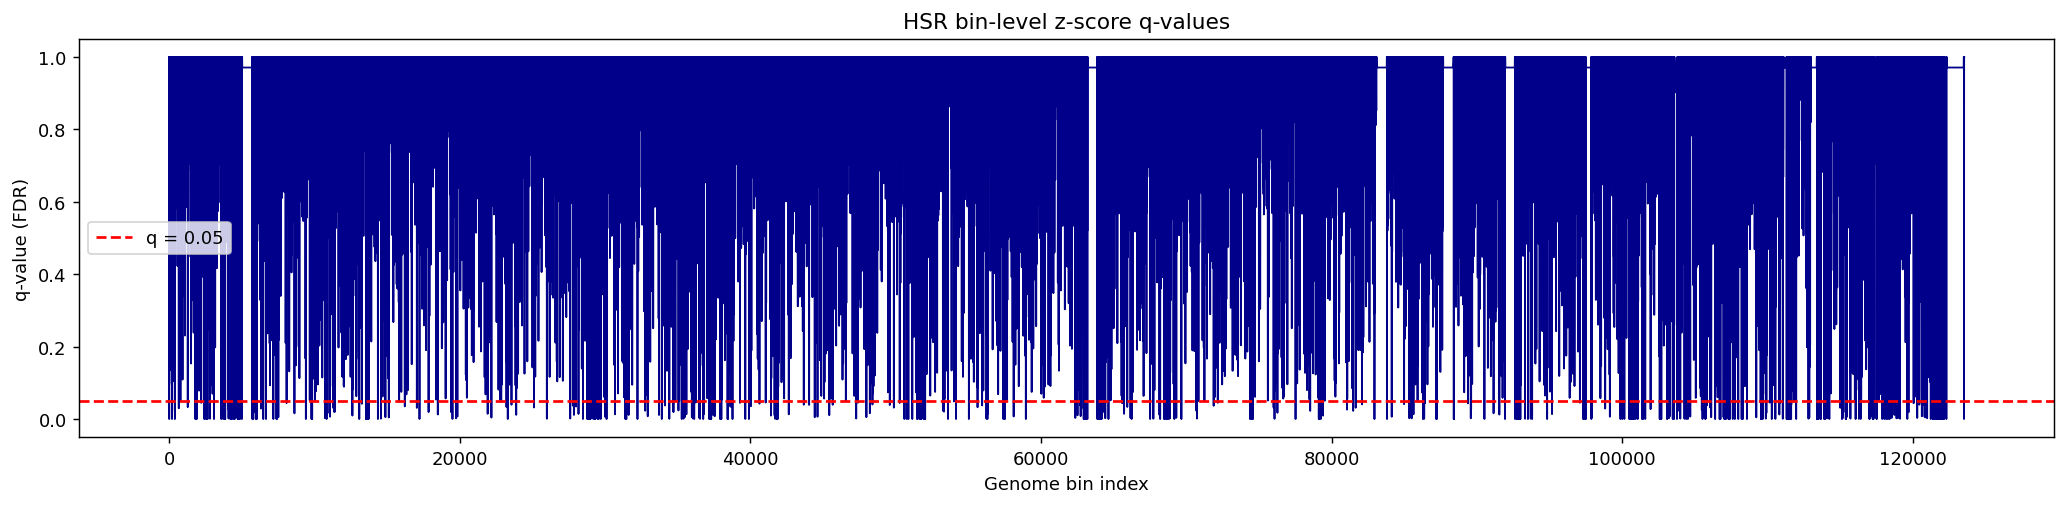

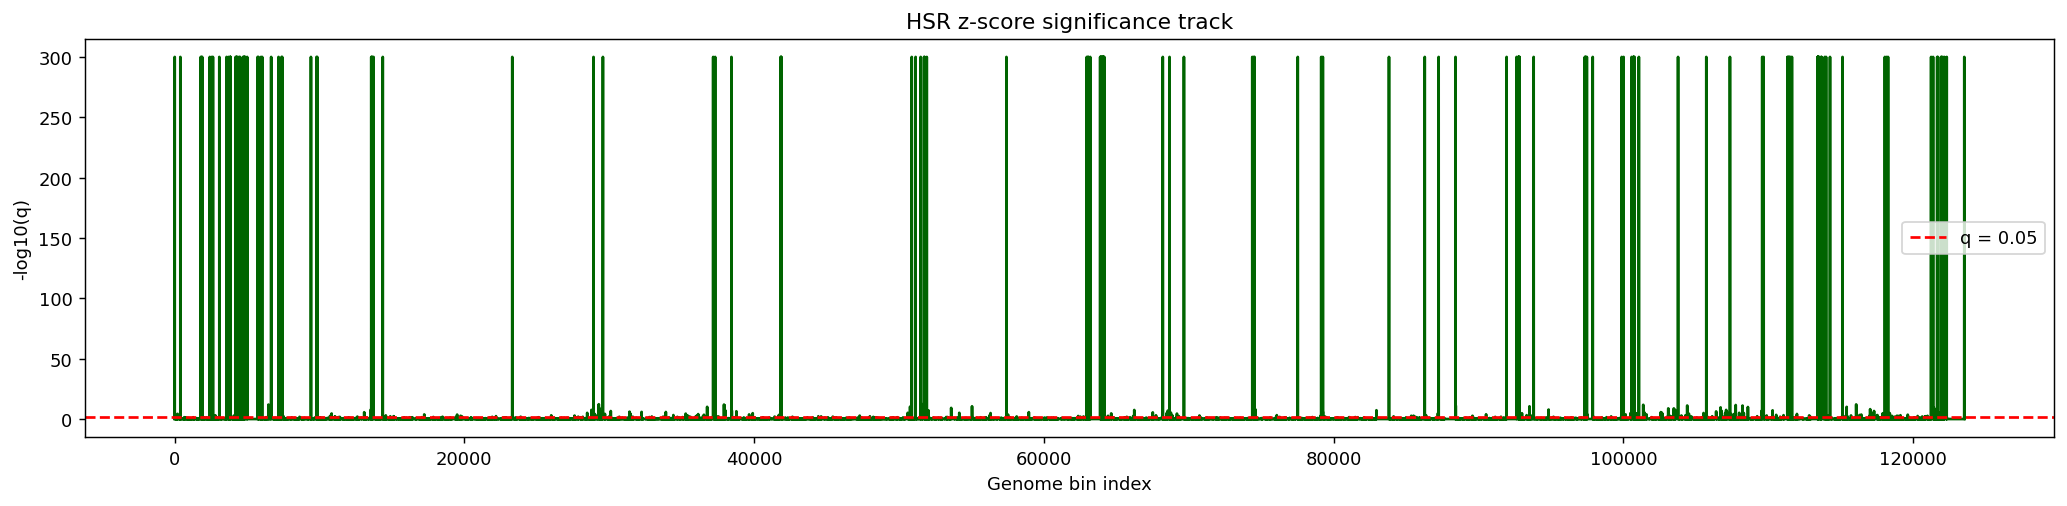

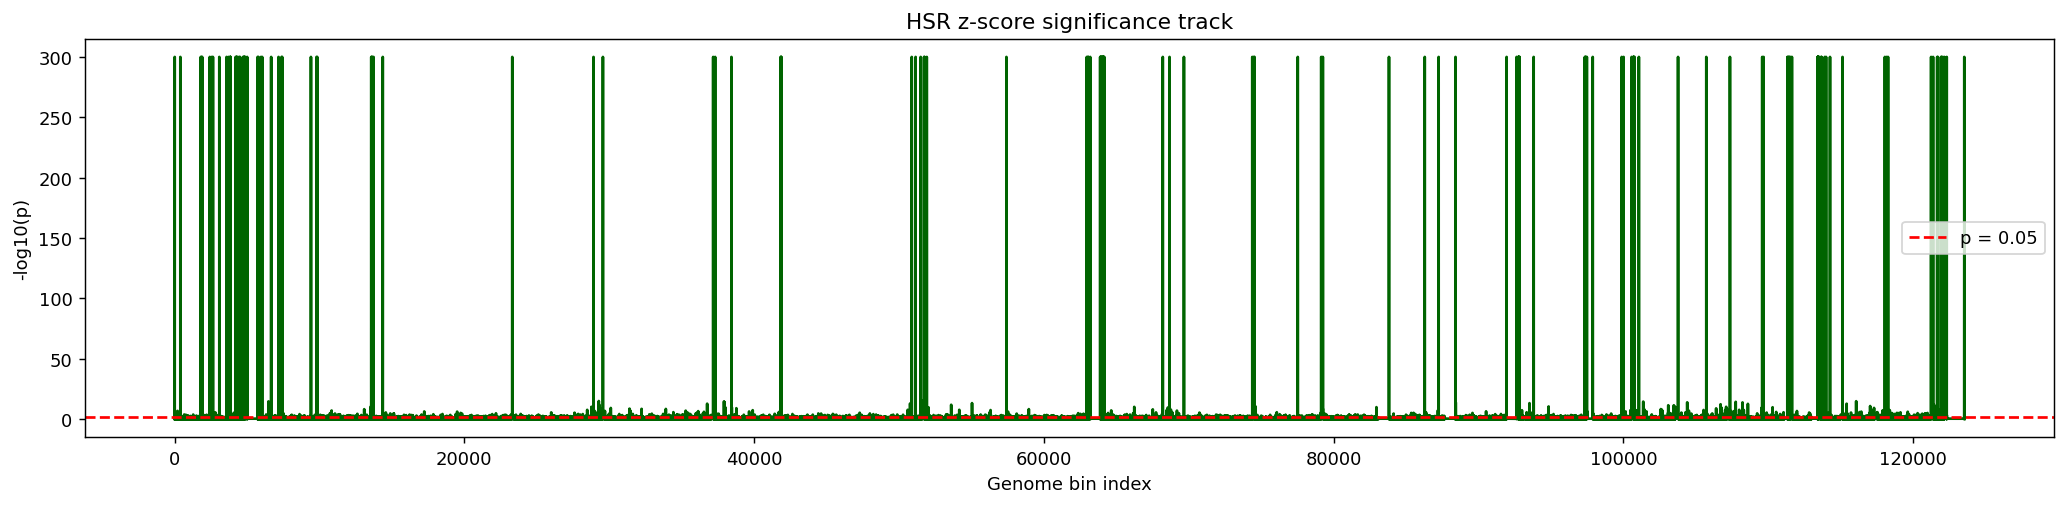

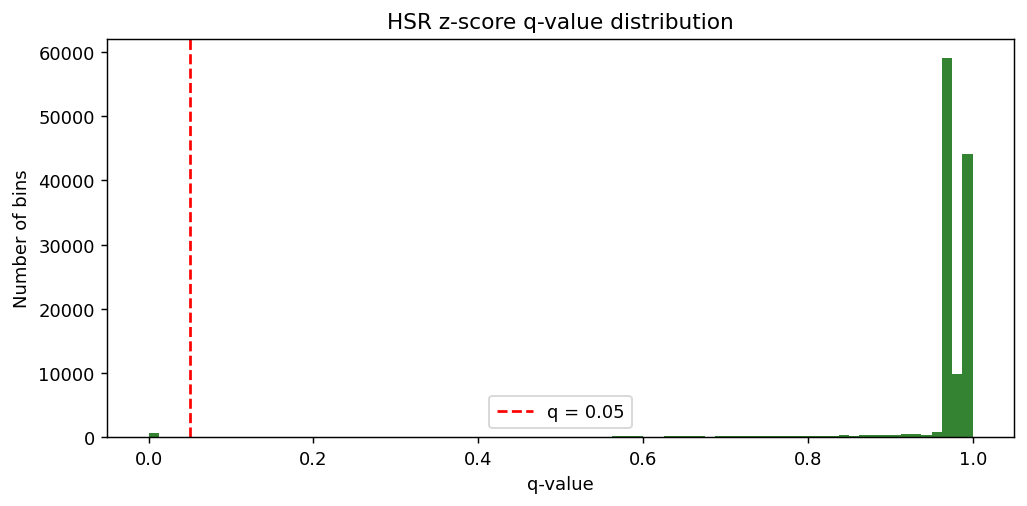

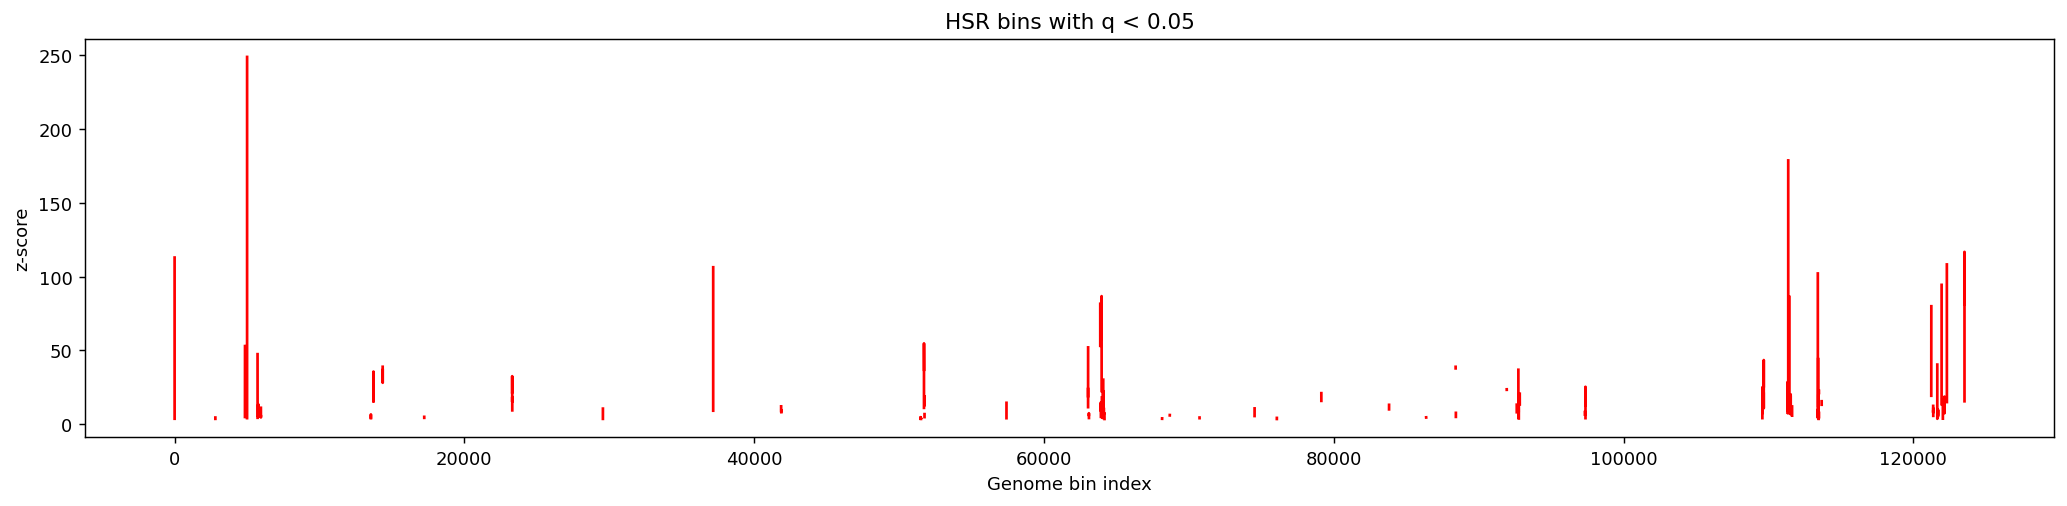

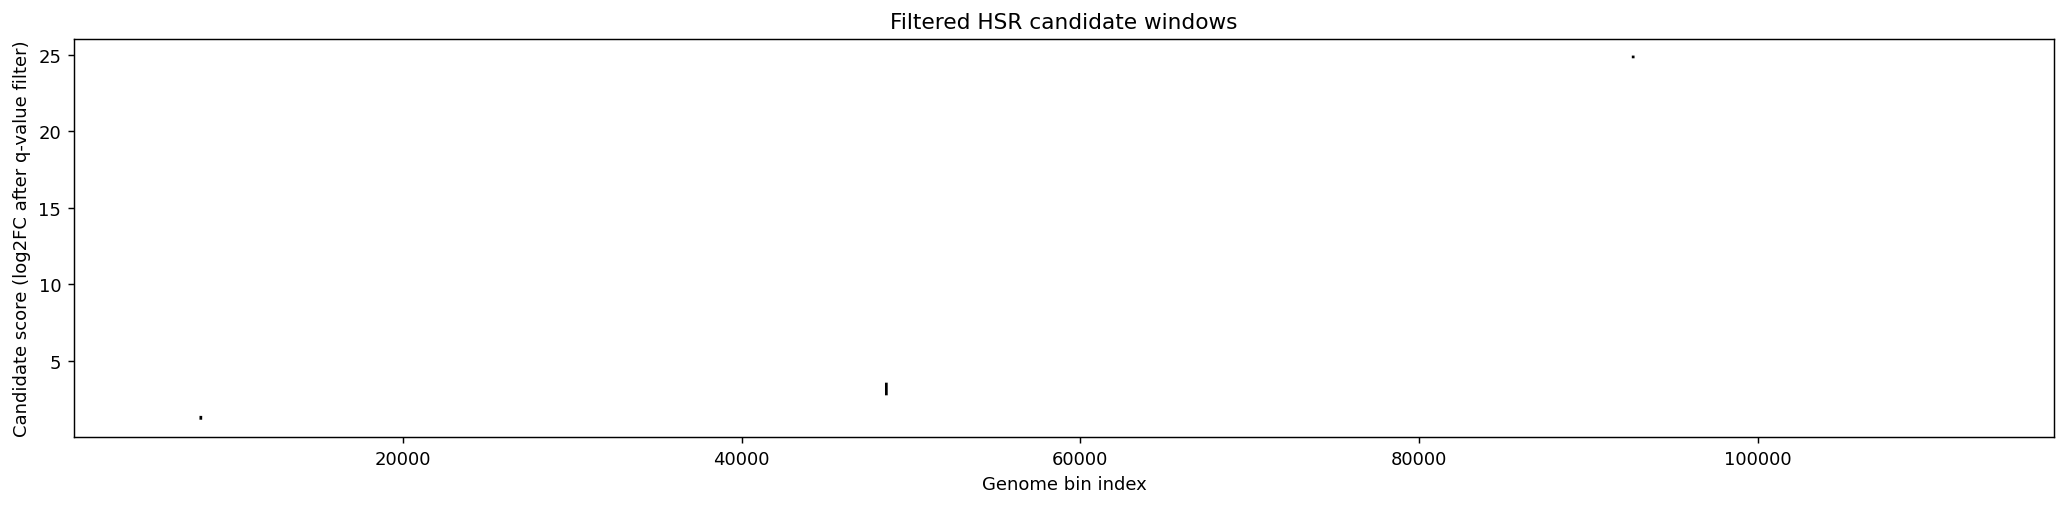

In [10]:

# =========================
# Plots
# =========================
x = np.arange(len(hsr_profile))

plt.figure(figsize=(16, 4))
plt.plot(x, hsr_profile, label="HSR ecDNA→genome profile", alpha=0.9)
plt.plot(x, reg_profile, label="Regular ecDNA→genome profile", alpha=0.9)
plt.xlabel("Genome bin index")
plt.ylabel(f"Mean normalized interaction across ecDNA bins ({BALANCE})")
plt.title("Genome-wide ecDNA→genome interaction profiles")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "profiles_hsr_vs_reg.png"), dpi=200)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x, per_bin_log2fc, color="purple")
plt.axhline(0, linestyle="--", color="gray")
plt.axhline(LOG2FC_THRESHOLD, linestyle="--", color="orange", label=f"log2FC threshold = {LOG2FC_THRESHOLD}")
plt.xlabel("Genome bin index")
plt.ylabel("log2(HSR / regular)")
plt.title("Per-bin HSR vs regular log2 fold change")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "per_bin_log2fc_hsr_vs_reg.png"), dpi=200)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x, hsr_wilcox["neglog10q"], color="darkred")
plt.axhline(-np.log10(QVAL_THRESHOLD), linestyle="--", color="orange",
            label=f"q threshold = {QVAL_THRESHOLD}")
plt.xlabel("Genome bin index")
plt.ylabel("-log10(q-value)")
plt.title("Local enrichment score in HSR")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "hsr_neglog10q.png"), dpi=200)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x, reg_wilcox["neglog10q"], color="darkblue")
plt.axhline(-np.log10(QVAL_THRESHOLD), linestyle="--", color="orange",
            label=f"q threshold = {QVAL_THRESHOLD}")
plt.xlabel("Genome bin index")
plt.ylabel("-log10(q-value)")
plt.title("Local enrichment score in regular ecDNA")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "reg_neglog10q.png"), dpi=200)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x, hsr_z["zscores"], color="darkgreen")
plt.axhline(2.0, linestyle="--", color="gray", label="z = 2")
plt.axhline(3.0, linestyle="--", color="orange", label="z = 3")
plt.xlabel("Genome bin index")
plt.ylabel("z-score")
plt.title("Bin-level local z-score enrichment in HSR")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "hsr_zscore_track.png"), dpi=200)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x, reg_z["zscores"], color="steelblue")
plt.axhline(2.0, linestyle="--", color="gray", label="z = 2")
plt.axhline(3.0, linestyle="--", color="orange", label="z = 3")
plt.xlabel("Genome bin index")
plt.ylabel("z-score")
plt.title("Bin-level local z-score enrichment in regular ecDNA")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "reg_zscore_track.png"), dpi=200)
plt.show()

plt.figure(figsize=(16,4))
plt.plot(x, hsr_z["pvals"], color="purple", linewidth=1)
plt.axhline(0.05, linestyle="--", color="red", label="p = 0.05")
plt.xlabel("Genome bin index")
plt.ylabel("p-value")
plt.title("HSR bin-level z-score p-values")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "hsr_zscore_pvals.png"), dpi=200)
plt.show()

plt.figure(figsize=(16,4))
plt.plot(x, hsr_z["qvals"], color="darkblue", linewidth=1)
plt.axhline(0.05, linestyle="--", color="red", label="q = 0.05")
plt.xlabel("Genome bin index")
plt.ylabel("q-value (FDR)")
plt.title("HSR bin-level z-score q-values")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "hsr_zscore_qvals.png"), dpi=200)
plt.show()

hsr_neglog10q = -np.log10(np.clip(hsr_z["qvals"], 1e-300, 1))
plt.figure(figsize=(16,4))
plt.plot(x, hsr_neglog10q, color="darkgreen")
plt.axhline(-np.log10(0.05), linestyle="--", color="red",
            label="q = 0.05")
plt.xlabel("Genome bin index")
plt.ylabel("-log10(q)")
plt.title("HSR z-score significance track")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "hsr_zscore_neglog10q.png"), dpi=200)
plt.show()

hsr_neglog10p = -np.log10(np.clip(hsr_z["pvals"], 1e-300, 1))
plt.figure(figsize=(16,4))
plt.plot(x, hsr_neglog10p, color="darkgreen")
plt.axhline(-np.log10(0.05), linestyle="--", color="red",
            label="p = 0.05")
plt.xlabel("Genome bin index")
plt.ylabel("-log10(p)")
plt.title("HSR z-score significance track")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "hsr_zscore_neglog10p.png"), dpi=200)
plt.show()


plt.figure(figsize=(8,4))
plt.hist(hsr_z["qvals"][np.isfinite(hsr_z["qvals"])],
         bins=80,
         color="darkgreen",
         alpha=0.8)
plt.axvline(0.05, linestyle="--", color="red", label="q = 0.05")
plt.xlabel("q-value")
plt.ylabel("Number of bins")
plt.title("HSR z-score q-value distribution")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "hsr_zscore_qval_hist.png"), dpi=200)
plt.show()

sig_mask = hsr_z["qvals"] < 0.05
plt.figure(figsize=(16,4))
plt.plot(x, np.where(sig_mask, hsr_z["zscores"], np.nan),
         color="red")
plt.xlabel("Genome bin index")
plt.ylabel("z-score")
plt.title("HSR bins with q < 0.05")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "hsr_zscore_significant_bins.png"), dpi=200)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x, np.where(candidate_mask_w, window_log2fc, np.nan), color="black")
plt.xlabel("Genome bin index")
plt.ylabel("Candidate score (log2FC after q-value filter)")
plt.title("Filtered HSR candidate windows")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "filtered_hsr_candidates.png"), dpi=200)
plt.show()
